# Week 9 Phase 2.1R — the simple width-change control

**If the melt-pool width goes 20 → 30 between two neighbouring analysis points, that is a change of +10. Do Keyhole simulations have bigger such changes, and does knowing them help us predict Keyhole better than `[P, VX, LS, ST]` alone?**

This notebook reads the generated artifacts. The engine is `src/week9_phase2_1r_simple_width_change_control.py`.


In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import display, Image
pd.set_option('display.width', 190)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 90)
ROOT = Path.cwd().parents[1] if Path.cwd().name == 'week_09' else Path.cwd()
OUT = ROOT / 'outputs' / 'week9_phase2_1r_simple_width_change_control'
assert OUT.is_dir(), OUT


## 1. What did we actually ask?

Ioan suggested checking whether the way the melt-pool width changes over time carries Keyhole information.

The simplest possible version: look at two neighbouring analysis points. If the width is **20 µm** at one and **30 µm** at the next, the change is **+10**. If it then goes 30 → 33 that is **+3**, and 33 → 31 is **−2**. So one simulation becomes a short list of numbers like `[+10, +3, -2, ...]`, and that list is what we study.

**A strict naming rule.** These are *consecutive resampled analysis points*, not raw solver timesteps. The raw solver has ~75,000 steps per simulation at dt ≈ 0.018 µs, where the step-to-step width change is jitter (~0.005 µm, and the width goes *down* about half the time). A 'biggest raw one-step jump' would just find the largest numerical artifact. At 201 analysis points the gap is ≈ 6.8 µs, which is where a 20 → 30 µm change is a real event.


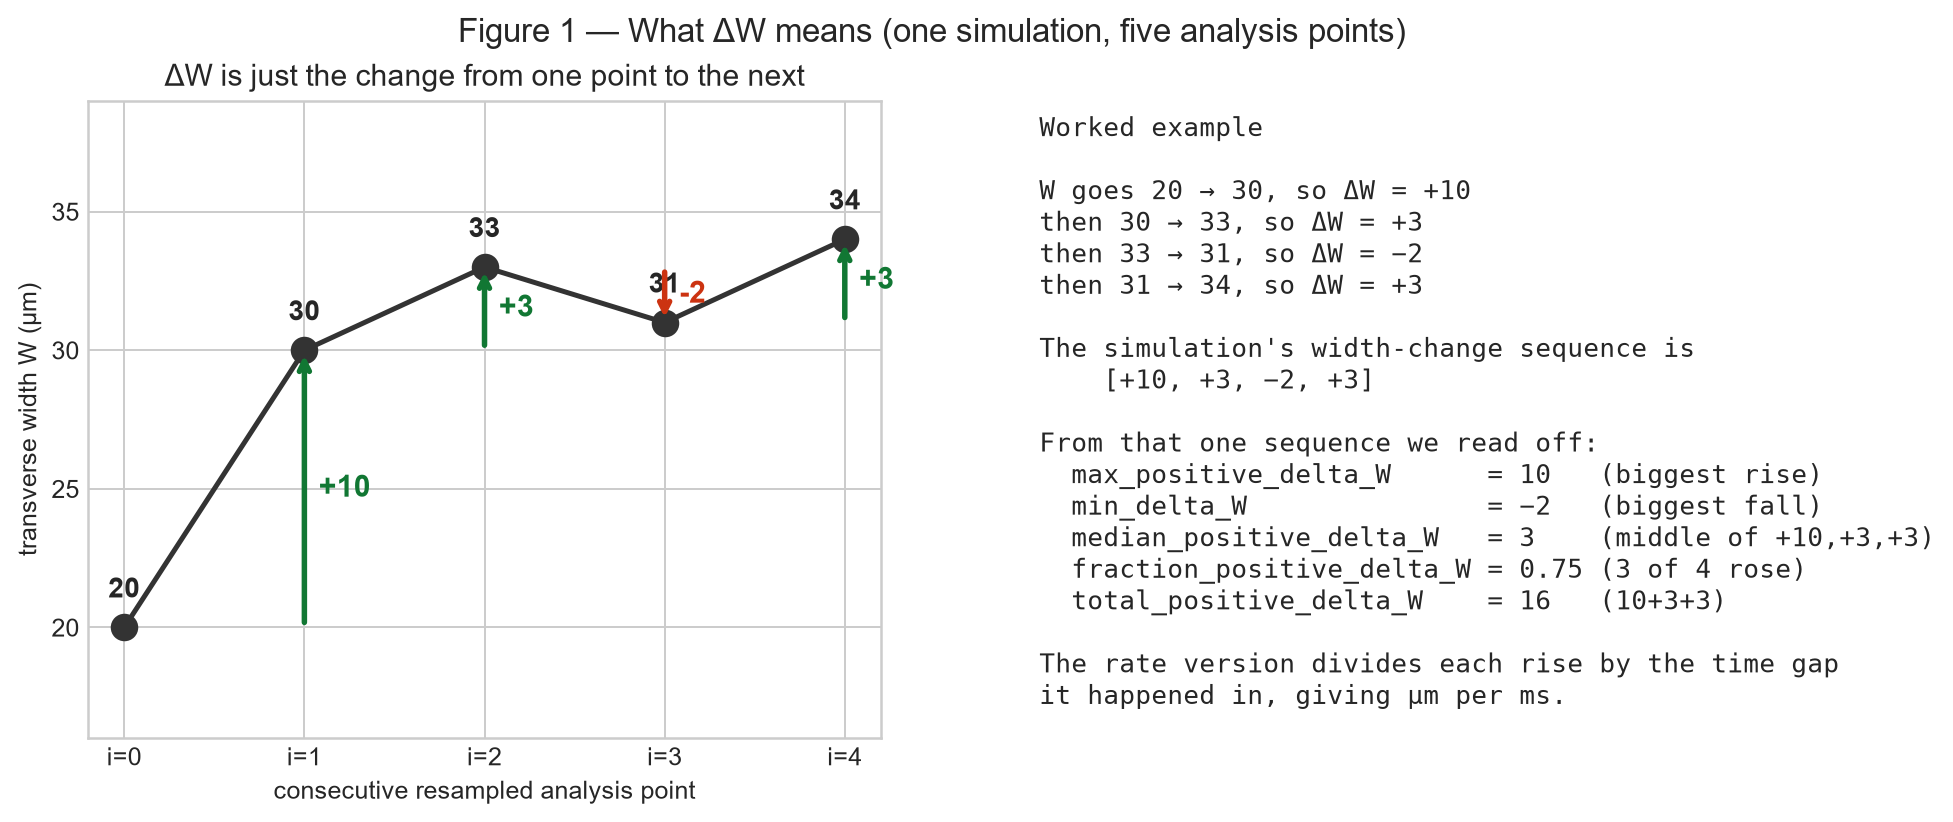

In [2]:
display(Image(filename=OUT/'figures'/'01_delta_W_construction.png'))


## 2. The transition table, and why we do NOT treat it as thousands of experiments

Every consecutive pair of analysis points gives one row: the two widths, the time gap, the change `delta_W`, and the rate `delta_W / delta_t`.

But the Keyhole label belongs to the **whole simulation**, not to a single transition. A simulation with 200 transitions is one labelled experiment, not 200. So the table is used for building features and drawing pictures, and every train/test split stays grouped at the simulation level on the frozen folds.


70,000 transition rows from 350 simulations


,simulation_id,analysis_point_i,W_i_um,W_i_plus_1_um,delta_t_ms,delta_W_um,width_rate_um_per_ms,has_keyhole
0,P-100p408926704_VX-0p564694322144_LS-6p38706769001e-05_ST-381p633419878_M-TI64_XI-0p00...,0,4.0000,31.1628,0.0081,27.1628,3351.6833,0
1,P-100p408926704_VX-0p564694322144_LS-6p38706769001e-05_ST-381p633419878_M-TI64_XI-0p00...,1,31.1628,51.8675,0.0081,20.7048,2554.8113,0
2,P-100p408926704_VX-0p564694322144_LS-6p38706769001e-05_ST-381p633419878_M-TI64_XI-0p00...,2,51.8675,56.3105,0.0081,4.4430,548.2304,0
3,P-100p408926704_VX-0p564694322144_LS-6p38706769001e-05_ST-381p633419878_M-TI64_XI-0p00...,3,56.3105,63.3255,0.0081,7.0149,865.5916,0
4,P-100p408926704_VX-0p564694322144_LS-6p38706769001e-05_ST-381p633419878_M-TI64_XI-0p00...,4,63.3255,71.3482,0.0081,8.0227,989.9438,0
5,P-100p408926704_VX-0p564694322144_LS-6p38706769001e-05_ST-381p633419878_M-TI64_XI-0p00...,5,71.3482,66.9750,0.0081,-4.3731,-539.6130,0


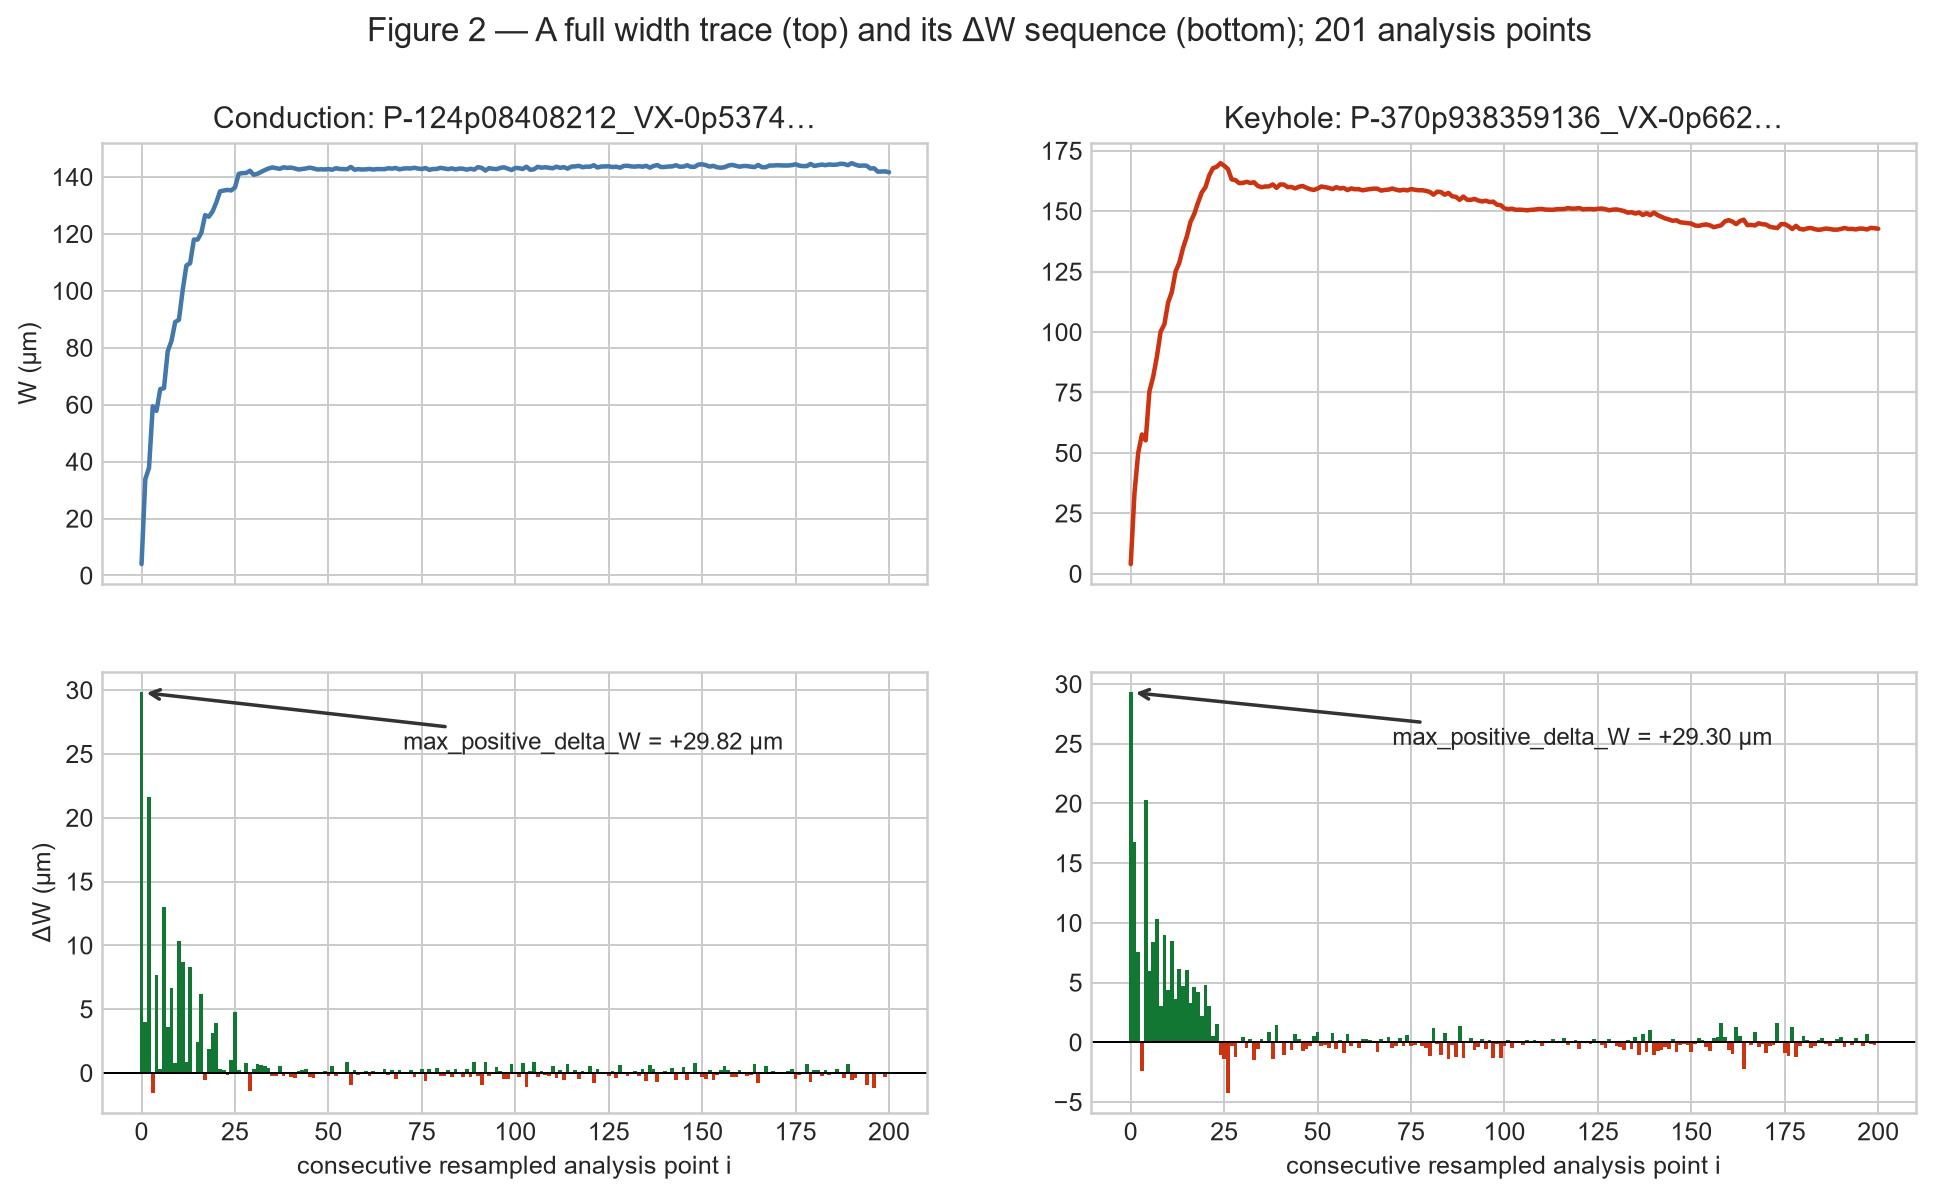

In [3]:
t = pd.read_csv(OUT/'transition_table_201.csv.gz')
print(f'{len(t):,} transition rows from {t.simulation_id.nunique()} simulations')
display(t.head(6)[['simulation_id','analysis_point_i','W_i_um','W_i_plus_1_um','delta_t_ms','delta_W_um','width_rate_um_per_ms','has_keyhole']].round(4))
display(Image(filename=OUT/'figures'/'02_example_trace_and_delta.png'))


## 3. The small, interpretable feature set

From the sequence `[+10, +3, -2, +1]` we read off, in plain words:

* `max_positive_delta_W` = **10** — the biggest single rise
* `min_delta_W` = **−2** — the biggest single fall
* `median_positive_delta_W` = **3** — middle of the rises `[+10, +3, +1]`
* `fraction_positive_delta_W` = **0.75** — 3 of the 4 transitions went up
* `total_positive_delta_W` = **14** — 10 + 3 + 1

Then the same three headline quantities again after dividing each change by the time gap it happened in, which turns µm into µm/ms. That is the whole family — deliberately small, so each number can be explained in one sentence.


In [4]:
s = pd.read_csv(OUT/'univariate_separation.csv')
display(s[['feature','plain_english','worked_example']])


,feature,plain_english,worked_example
0,max_positive_delta_W,largest increase in transverse width between two consecutive resampled analysis points,"sequence [+10, +3, -2, +1] -> the biggest rise is +10, so max_positive_delta_W = 10"
1,min_delta_W,"most negative transition, i.e. the largest single contraction","sequence [+10, +3, -2, +1] -> the most negative entry is -2, so min_delta_W = -2"
2,median_positive_delta_W,median of only the transitions where the width grew,"positives are [+10, +3, +1]; their median is 3, so median_positive_delta_W = 3"
3,fraction_positive_delta_W,share of transitions in which the width increased,"3 of the 4 transitions are positive, so fraction_positive_delta_W = 0.75"
4,total_positive_delta_W,"sum of every increase, i.e. total growth ignoring the shrinking steps","10 + 3 + 1 = 14, so total_positive_delta_W = 14"
5,max_positive_width_rate,largest increase divided by the time gap it happened in (um per ms),if the +10 um rise took 0.0068 ms then max_positive_width_rate = 10 / 0.0068 = 1471 um/ms
6,median_positive_width_rate,median of the positive rises after each is divided by its own time gap,"the positive rises [+10, +3, +1] become rates, and we take the middle one"
7,fraction_positive_width_rate,share of transitions with a positive rate -- identical to fraction_positive_delta_W be...,"3 of 4 positive -> 0.75, exactly the same number as fraction_positive_delta_W"


## 4. Do Keyhole simulations have bigger width jumps?

This is the child-simple question. For every simulation take one number — the biggest rise anywhere in it — and ask whether Keyhole simulations tend to have bigger ones.

These numbers are whole-sample and descriptive: they say whether a difference exists at all, **not** how well it would generalise. The honest held-out version is the next section.


,feature,conduction_median,keyhole_median,cliffs_delta,roc_auc_whole_sample,pr_auc_whole_sample
0,max_positive_delta_W,29.8192,29.2747,-0.2042,0.3979,0.1680
1,min_delta_W,-6.5037,-4.3227,0.1594,0.5797,0.2446
2,median_positive_delta_W,0.4989,0.4578,-0.0861,0.4569,0.2006
3,fraction_positive_delta_W,0.5375,0.5325,0.0001,0.5001,0.2150
4,total_positive_delta_W,220.0854,207.6500,0.0006,0.5003,0.2299
5,max_positive_width_rate,4682.1348,3550.6667,-0.3001,0.3499,0.1558
6,median_positive_width_rate,75.4412,65.9151,-0.2444,0.3778,0.1668
7,fraction_positive_width_rate,0.5375,0.5325,0.0001,0.5001,0.2150


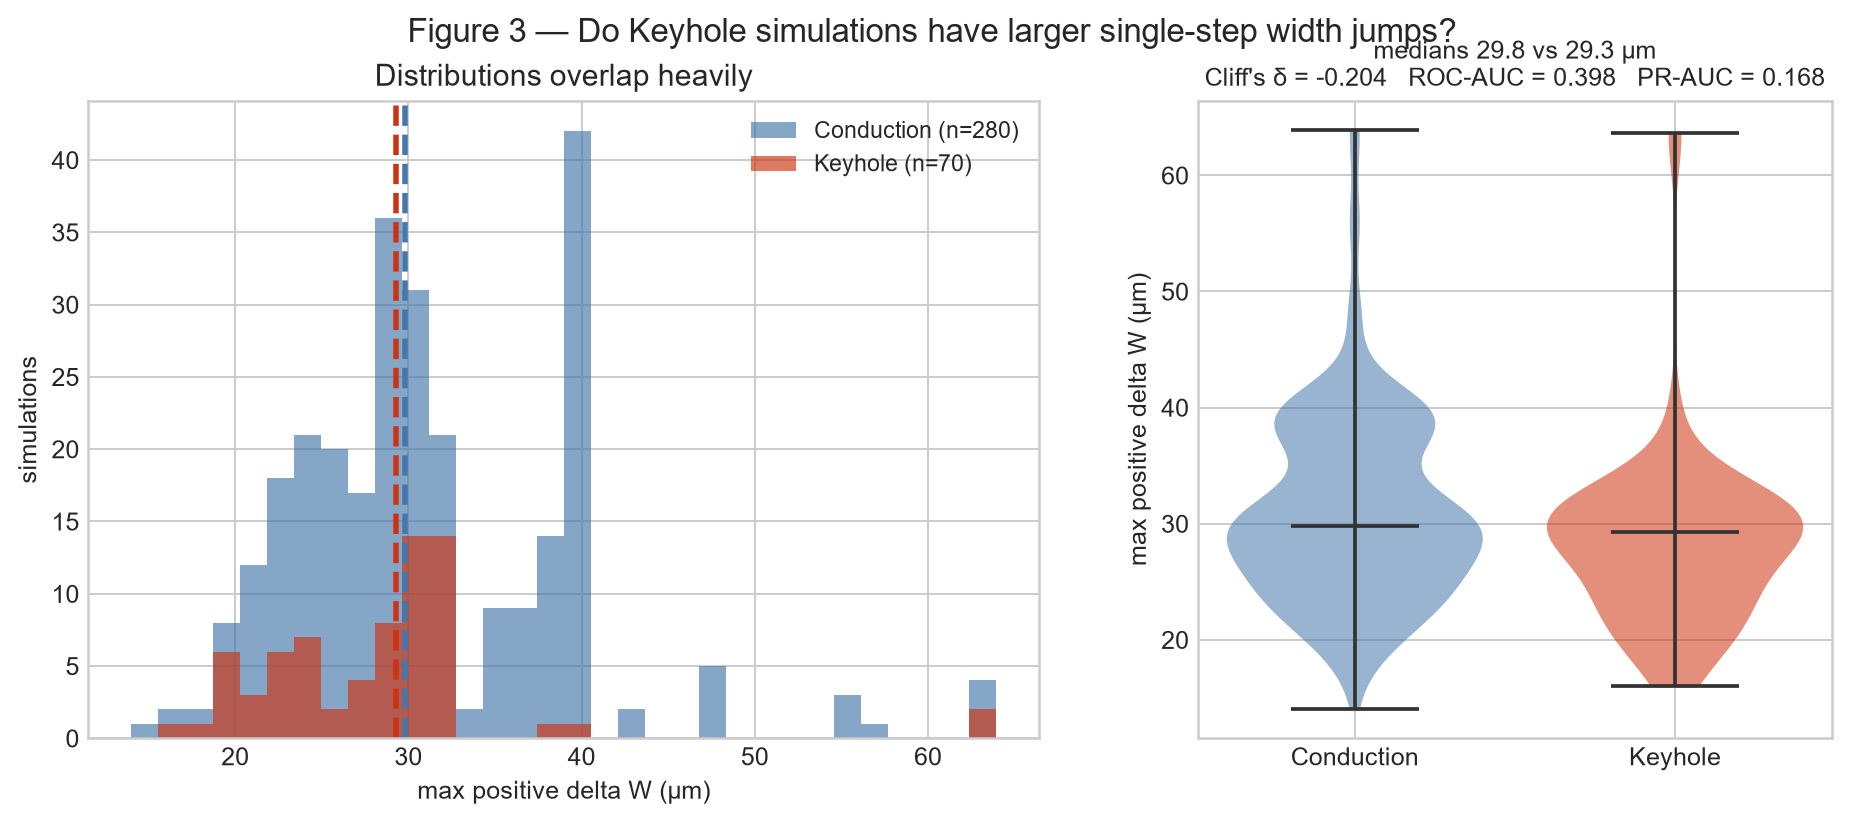

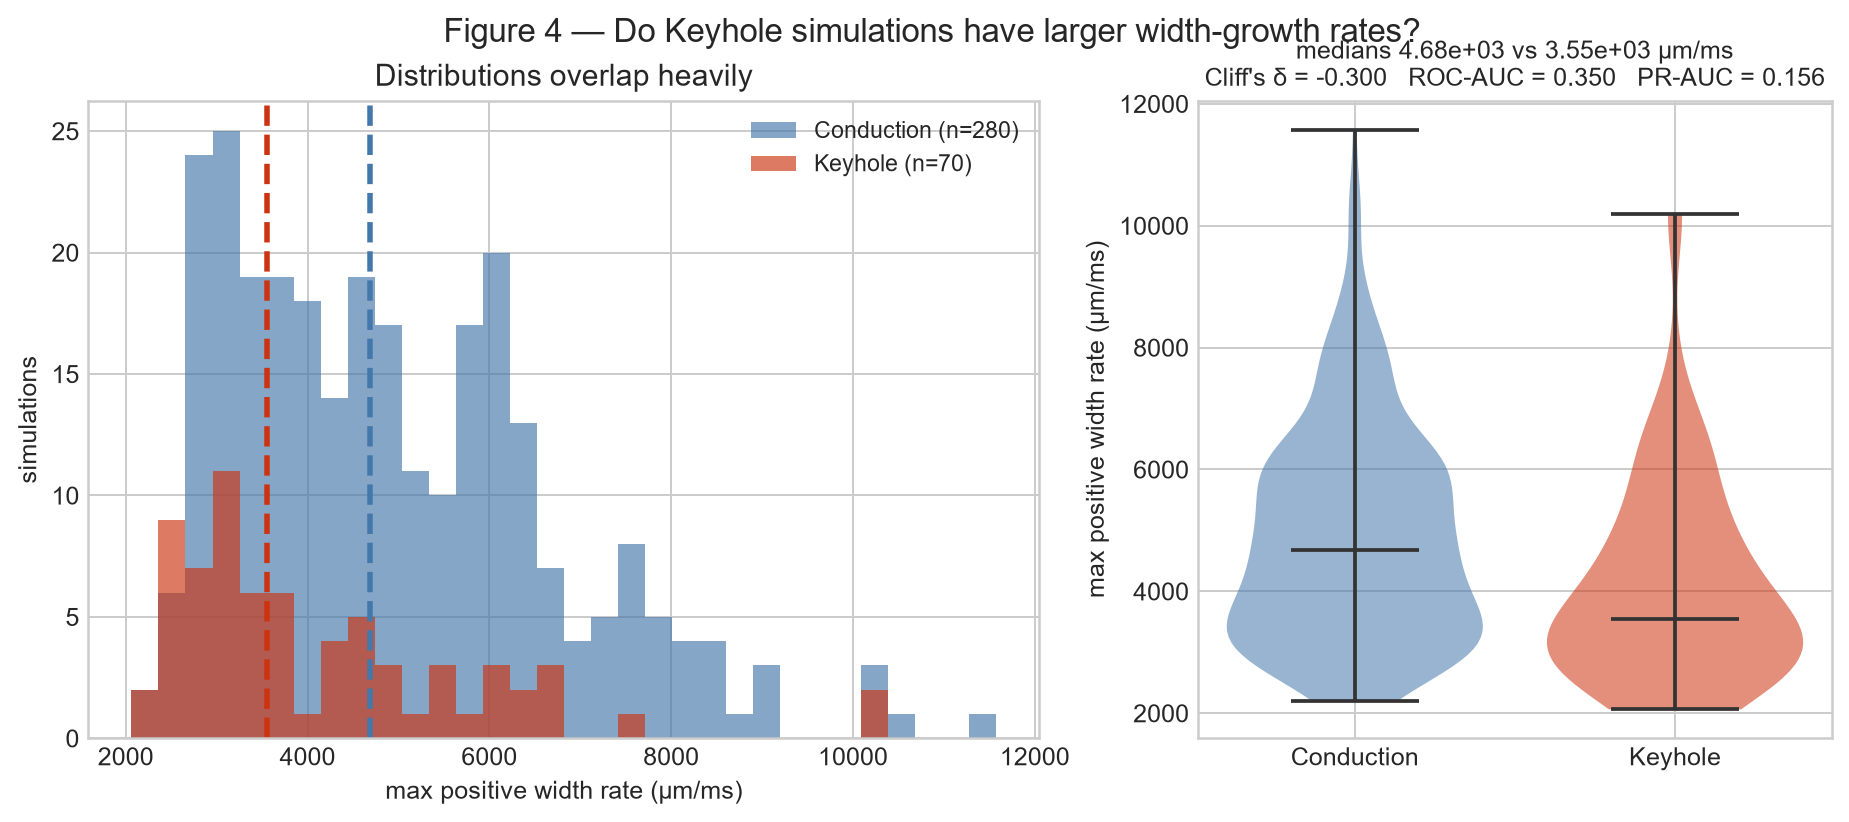

In [5]:
display(s[['feature','conduction_median','keyhole_median','cliffs_delta','roc_auc_whole_sample','pr_auc_whole_sample']].round(4))
display(Image(filename=OUT/'figures'/'03_max_positive_delta_W_distribution.png'))
display(Image(filename=OUT/'figures'/'04_max_positive_width_rate_distribution.png'))


## 5. The threshold experiment, done leak-free

The rule is exactly the intuitive one: **if the biggest width jump is larger than some threshold, call it Keyhole**.

The catch is where the threshold comes from. Picking one number using all 350 labels and then reporting its accuracy would be cheating. So inside each of the 100 frozen folds we choose the threshold using **only the training simulations**, freeze it, and apply it to the held-out ones. If the training values are `[4, 9, 12, 20]` with labels `[0, 0, 1, 1]`, the candidate cuts are the midpoints 6.5, 10.5 and 16, and 10.5 separates them perfectly, so 10.5 is chosen.


,feature,subset,learned_threshold_median,learned_threshold_iqr_low,learned_threshold_iqr_high,learned_threshold_min,learned_threshold_max,fraction_of_folds_choosing_below,majority_direction,folds,total_true_positive,total_false_negative,total_false_positive,total_true_negative,balanced_accuracy_mean,balanced_accuracy_sd_across_repeats,accuracy_mean,accuracy_sd_across_repeats,keyhole_recall_mean,keyhole_recall_sd_across_repeats,conduction_recall_mean,conduction_recall_sd_across_repeats,feature_roc_auc_mean,feature_roc_auc_sd_across_repeats,feature_pr_auc_mean,feature_pr_auc_sd_across_repeats
0,max_positive_delta_W,full,32.4080,32.4080,32.4080,31.6079,33.4576,1.0,below,100,1290,110,3775,1825,0.6239,0.0083,0.4452,0.0036,0.9218,0.0166,0.3260,0.0020,0.6013,0.0054,0.3156,0.0105
1,max_positive_delta_W,q20,32.4080,32.4080,32.4080,31.6079,33.4576,1.0,below,100,523,79,683,245,0.5643,0.0247,0.5013,0.0249,0.8661,0.0310,0.2624,0.0298,0.4768,0.0299,0.4545,0.0329
2,max_positive_delta_W,q30,32.4080,32.4080,32.4080,31.6079,33.4576,1.0,below,100,660,89,1089,392,0.5714,0.0190,0.4715,0.0183,0.8795,0.0286,0.2633,0.0204,0.4806,0.0246,0.3819,0.0211
3,max_positive_width_rate,full,3846.0258,3556.3669,4555.9668,2822.8208,5403.6545,1.0,below,100,738,662,2028,3572,0.5815,0.0166,0.6160,0.0305,0.5253,0.0532,0.6377,0.0479,0.6493,0.0044,0.3992,0.0105
4,max_positive_width_rate,q20,3846.0258,3556.3669,4555.9668,2822.8208,5403.6545,1.0,below,100,224,378,459,469,0.4334,0.0420,0.4522,0.0443,0.3644,0.0620,0.5025,0.0801,0.4417,0.0339,0.4770,0.0336
5,max_positive_width_rate,q30,3846.0258,3556.3669,4555.9668,2822.8208,5403.6545,1.0,below,100,284,465,713,768,0.4439,0.0377,0.4715,0.0411,0.3717,0.0677,0.5161,0.0699,0.4397,0.0282,0.4111,0.0263


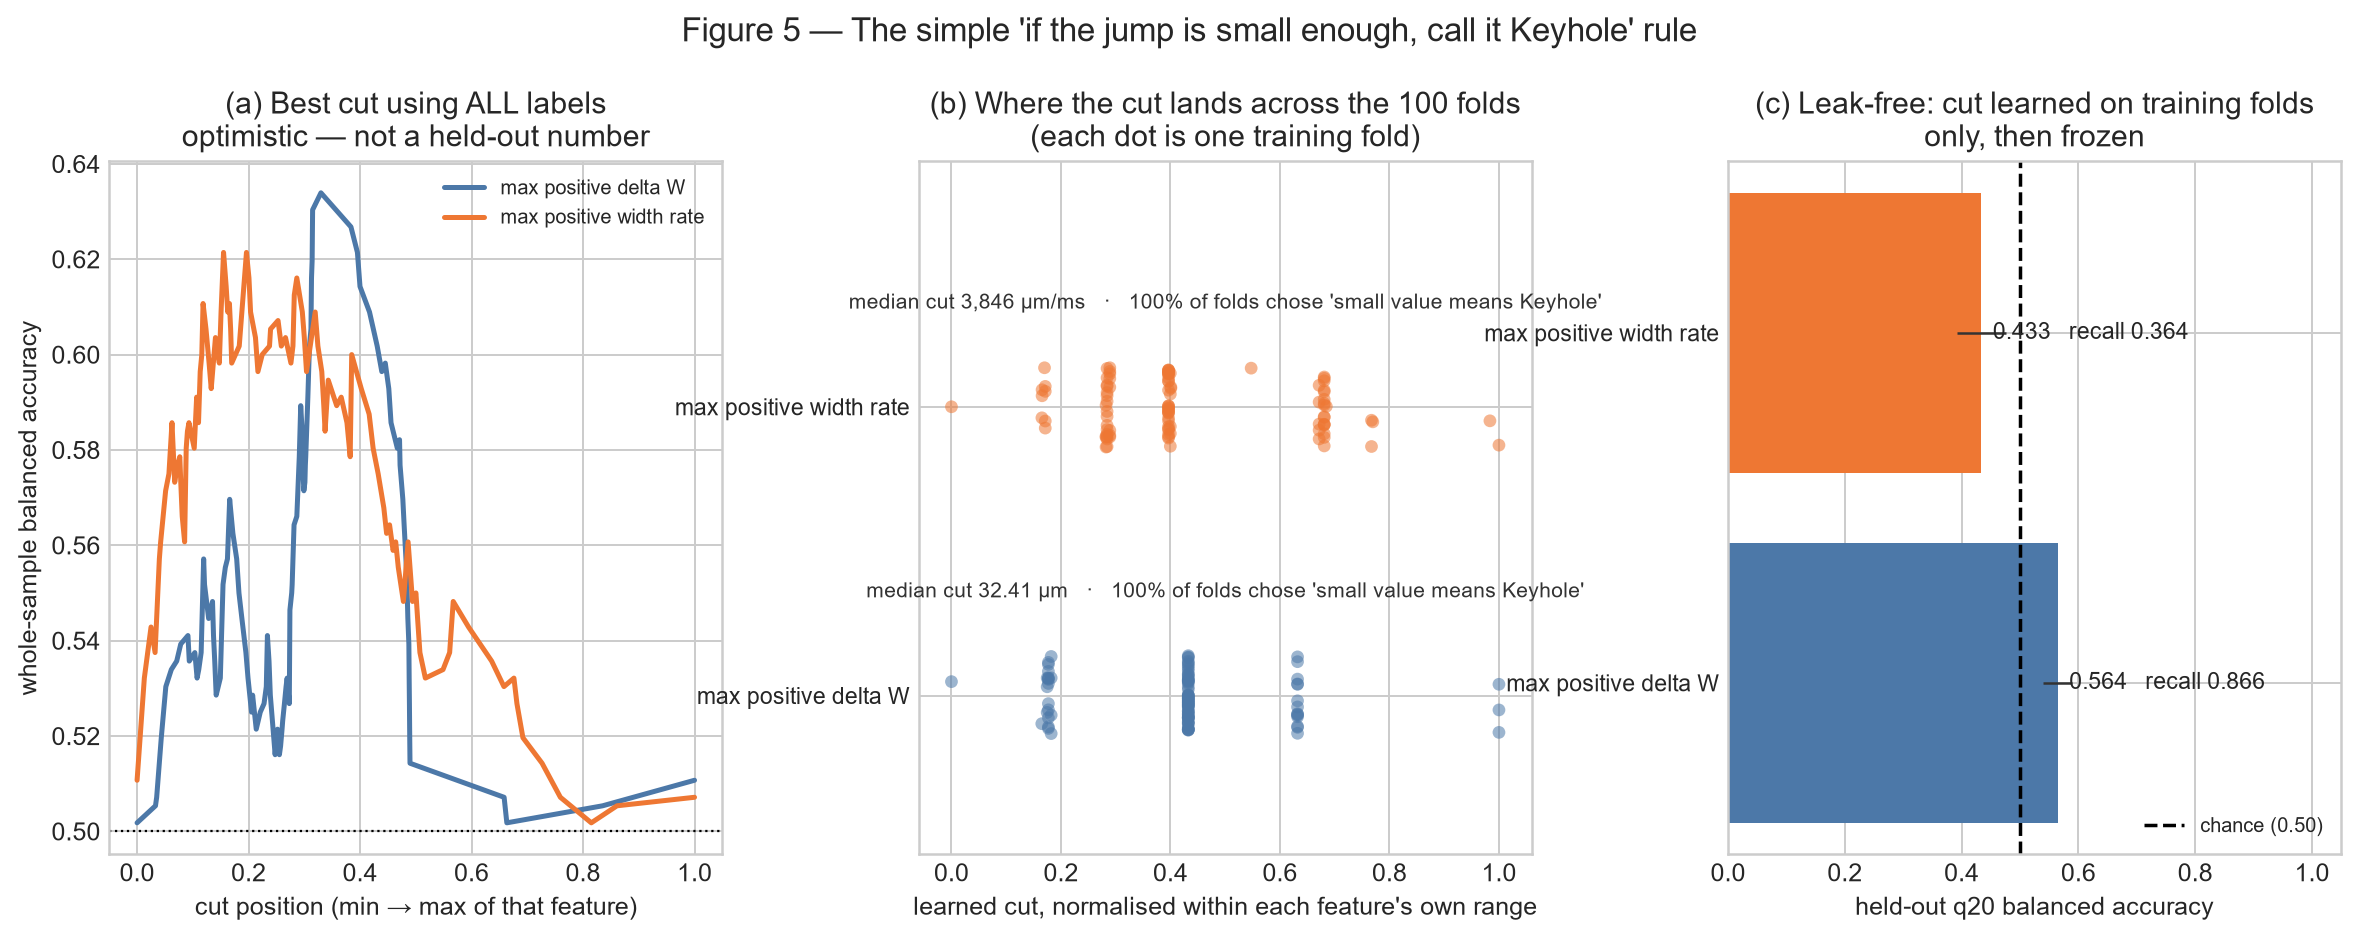

In [6]:
display(pd.read_csv(OUT/'threshold_summary.csv').round(4))
display(Image(filename=OUT/'figures'/'05_threshold_classifier.png'))


## 6. Does it help the real model?

Now the question that matters: the 4D GPC already knows `P`, `VX`, `LS` and `ST`. Does telling it the biggest width jump as well make it better?

Every model here is the same classifier — the ARD Matérn-3/2 GPC that Phase 1.12 established as the defensible specification. Only the list of input columns changes, so any difference is attributable to the features and not to the model.


metric,balanced_accuracy,brier_score,keyhole_recall,pr_auc,roc_auc
model,,,,,
abl_shape3_plus_robust_early_dWdt_20_um_per_ms,0.8777,0.1020,0.8441,0.8923,0.9299
abl_shape3_plus_robust_early_dWdt_40_um_per_ms,0.8741,0.1008,0.8377,0.8977,0.9319
abl_shape3_plus_robust_max_positive_dWdt_um_per_ms,0.8788,0.1004,0.8537,0.8968,0.9309
abl_shape3_plus_robust_median_positive_dWdt_um_per_ms,0.8794,0.0996,0.8506,0.8987,0.9332
abl_shape3_plus_robust_time_of_max_dWdt_tau,0.8728,0.1007,0.8492,0.8976,0.9326
gpc_4d,0.8739,0.1009,0.8288,0.8769,0.9244
gpc_4d_plus_max_delta_W,0.8830,0.0989,0.8555,0.8914,0.9325
gpc_4d_plus_max_delta_W_res101,0.8852,0.0971,0.8621,0.8976,0.9340
gpc_4d_plus_max_delta_W_res51,0.8658,0.1016,0.8158,0.8887,0.9308


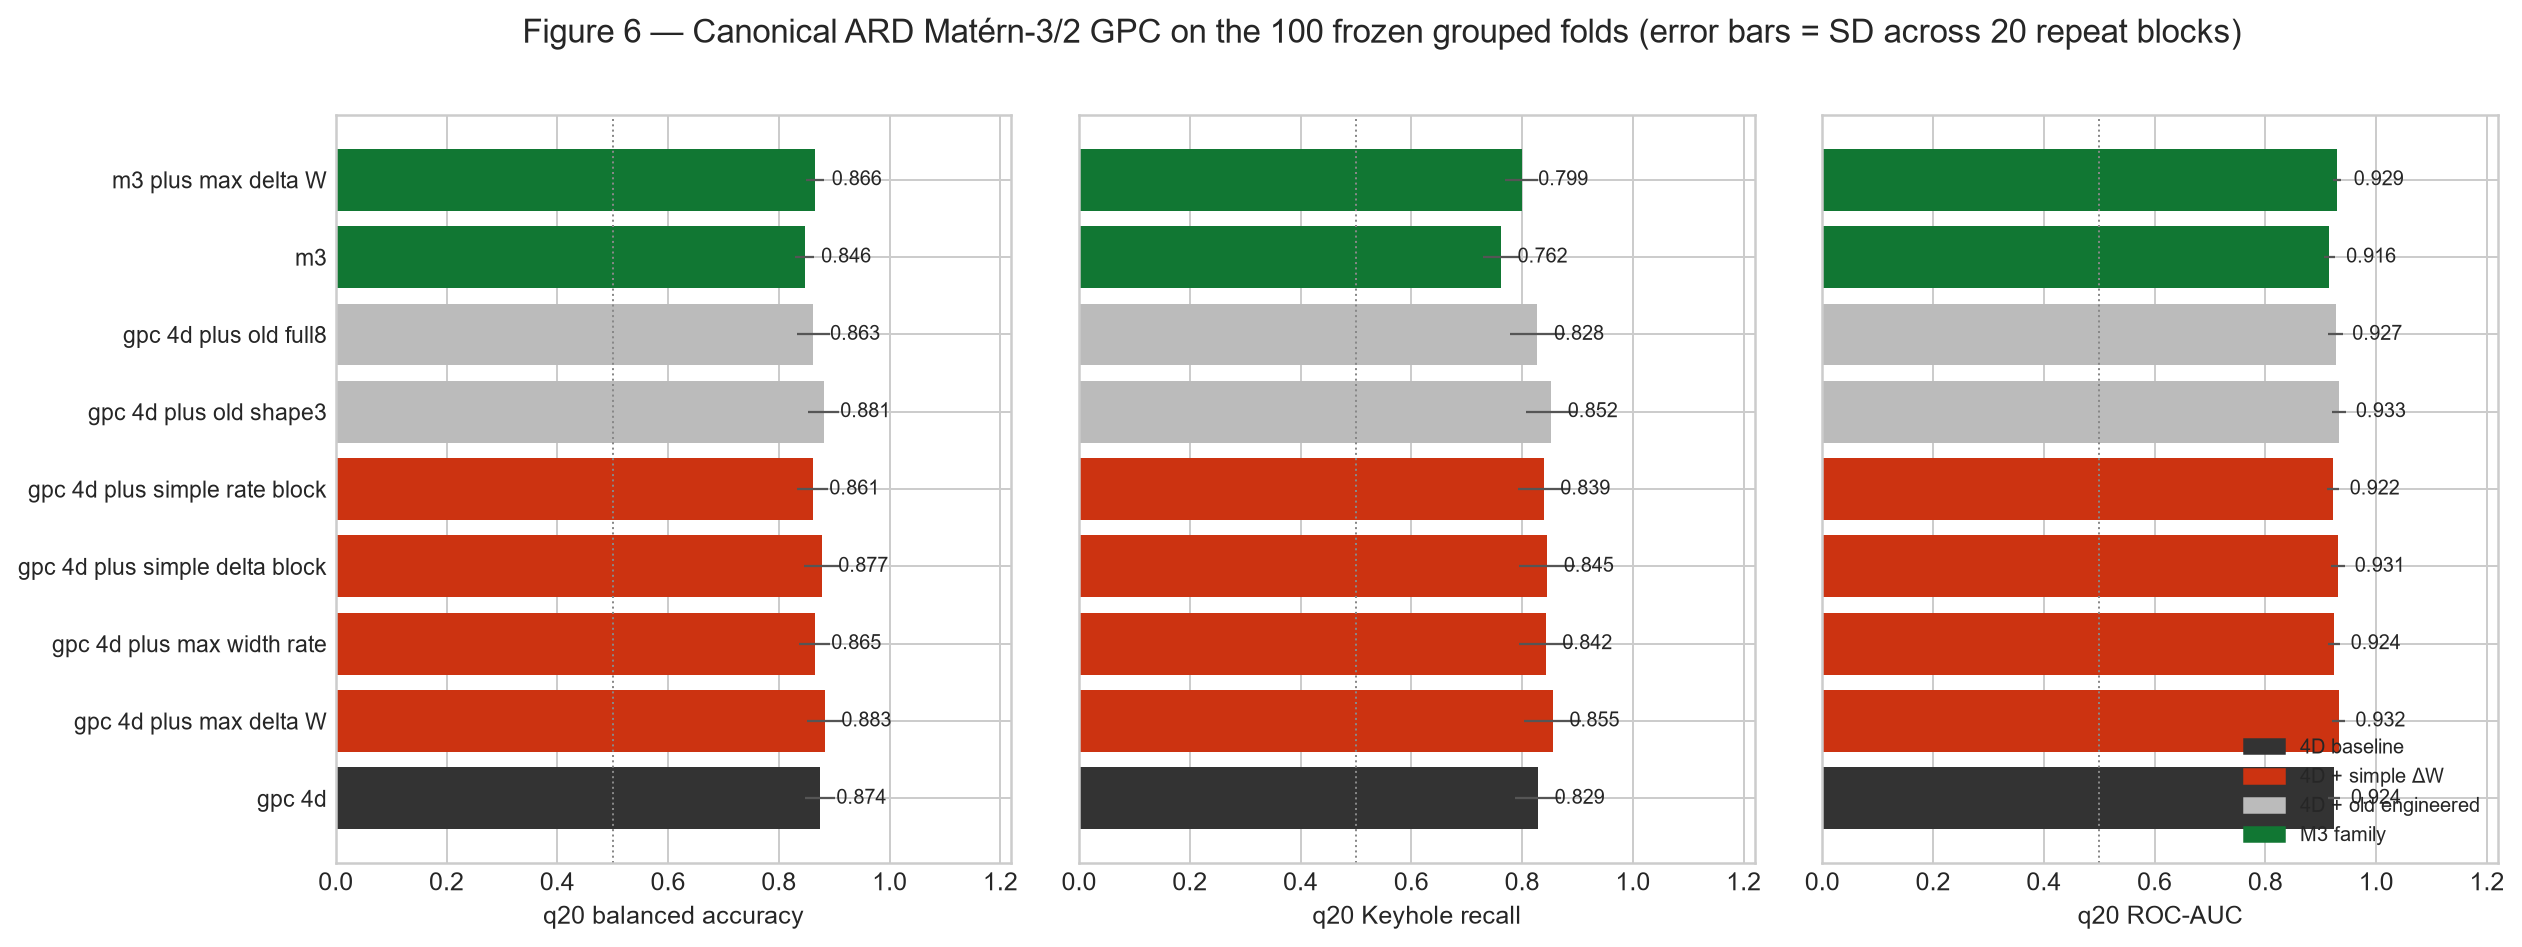

In [7]:
summary = pd.read_csv(OUT/'model_oof_summary.csv')
q20 = summary[(summary.subset=='q20') & summary.metric.isin(['balanced_accuracy','keyhole_recall','roc_auc','pr_auc','brier_score'])]
display(q20.pivot(index='model', columns='metric', values='mean').round(4))
display(Image(filename=OUT/'figures'/'06_model_comparison_gpc_m3.png'))


## 7. The primary contrast, and how it compares with M3

The single number this phase turns on is `gpc_4d_plus_max_delta_W − gpc_4d` on the q20 boundary band.

M3 is included as the reference point: physics logistic mean on `log h` plus an ARD Matérn-3/2 discrepancy GP. `m3_plus_max_delta_W` leaves the physics mean completely alone and only widens the discrepancy GP by one input, so M3's meaning is preserved.

This is a **predictive** comparison. It says nothing about acquisition.


,contrast,metric,mean_difference,ci_low,ci_high,holm_p_metric_family,verdict_after_holm
96,gpc_4d_plus_max_delta_W - gpc_4d,accuracy,0.0053,-0.0039,0.0139,0.2372,NO DETECTABLE DIFFERENCE
97,gpc_4d_plus_max_delta_W - gpc_4d,balanced_accuracy,0.0091,-0.0016,0.0197,0.2372,NO DETECTABLE DIFFERENCE
98,gpc_4d_plus_max_delta_W - gpc_4d,keyhole_recall,0.0267,0.0083,0.0448,0.0608,NO DETECTABLE DIFFERENCE
99,gpc_4d_plus_max_delta_W - gpc_4d,brier_score,-0.0020,-0.0036,-0.0003,0.1177,NO DETECTABLE DIFFERENCE
100,gpc_4d_plus_max_delta_W - gpc_4d,pr_auc,0.0145,0.0093,0.0200,0.0003,IMPROVES
101,gpc_4d_plus_max_delta_W - gpc_4d,roc_auc,0.0081,0.0047,0.0117,0.0010,IMPROVES
150,gpc_4d_plus_max_width_rate - gpc_4d,accuracy,-0.0144,-0.0244,-0.0047,0.0717,NO DETECTABLE DIFFERENCE
151,gpc_4d_plus_max_width_rate - gpc_4d,balanced_accuracy,-0.0093,-0.0202,0.0015,0.4630,NO DETECTABLE DIFFERENCE
152,gpc_4d_plus_max_width_rate - gpc_4d,keyhole_recall,0.0137,-0.0030,0.0300,0.4630,NO DETECTABLE DIFFERENCE
153,gpc_4d_plus_max_width_rate - gpc_4d,brier_score,0.0031,0.0008,0.0053,0.0725,NO DETECTABLE DIFFERENCE


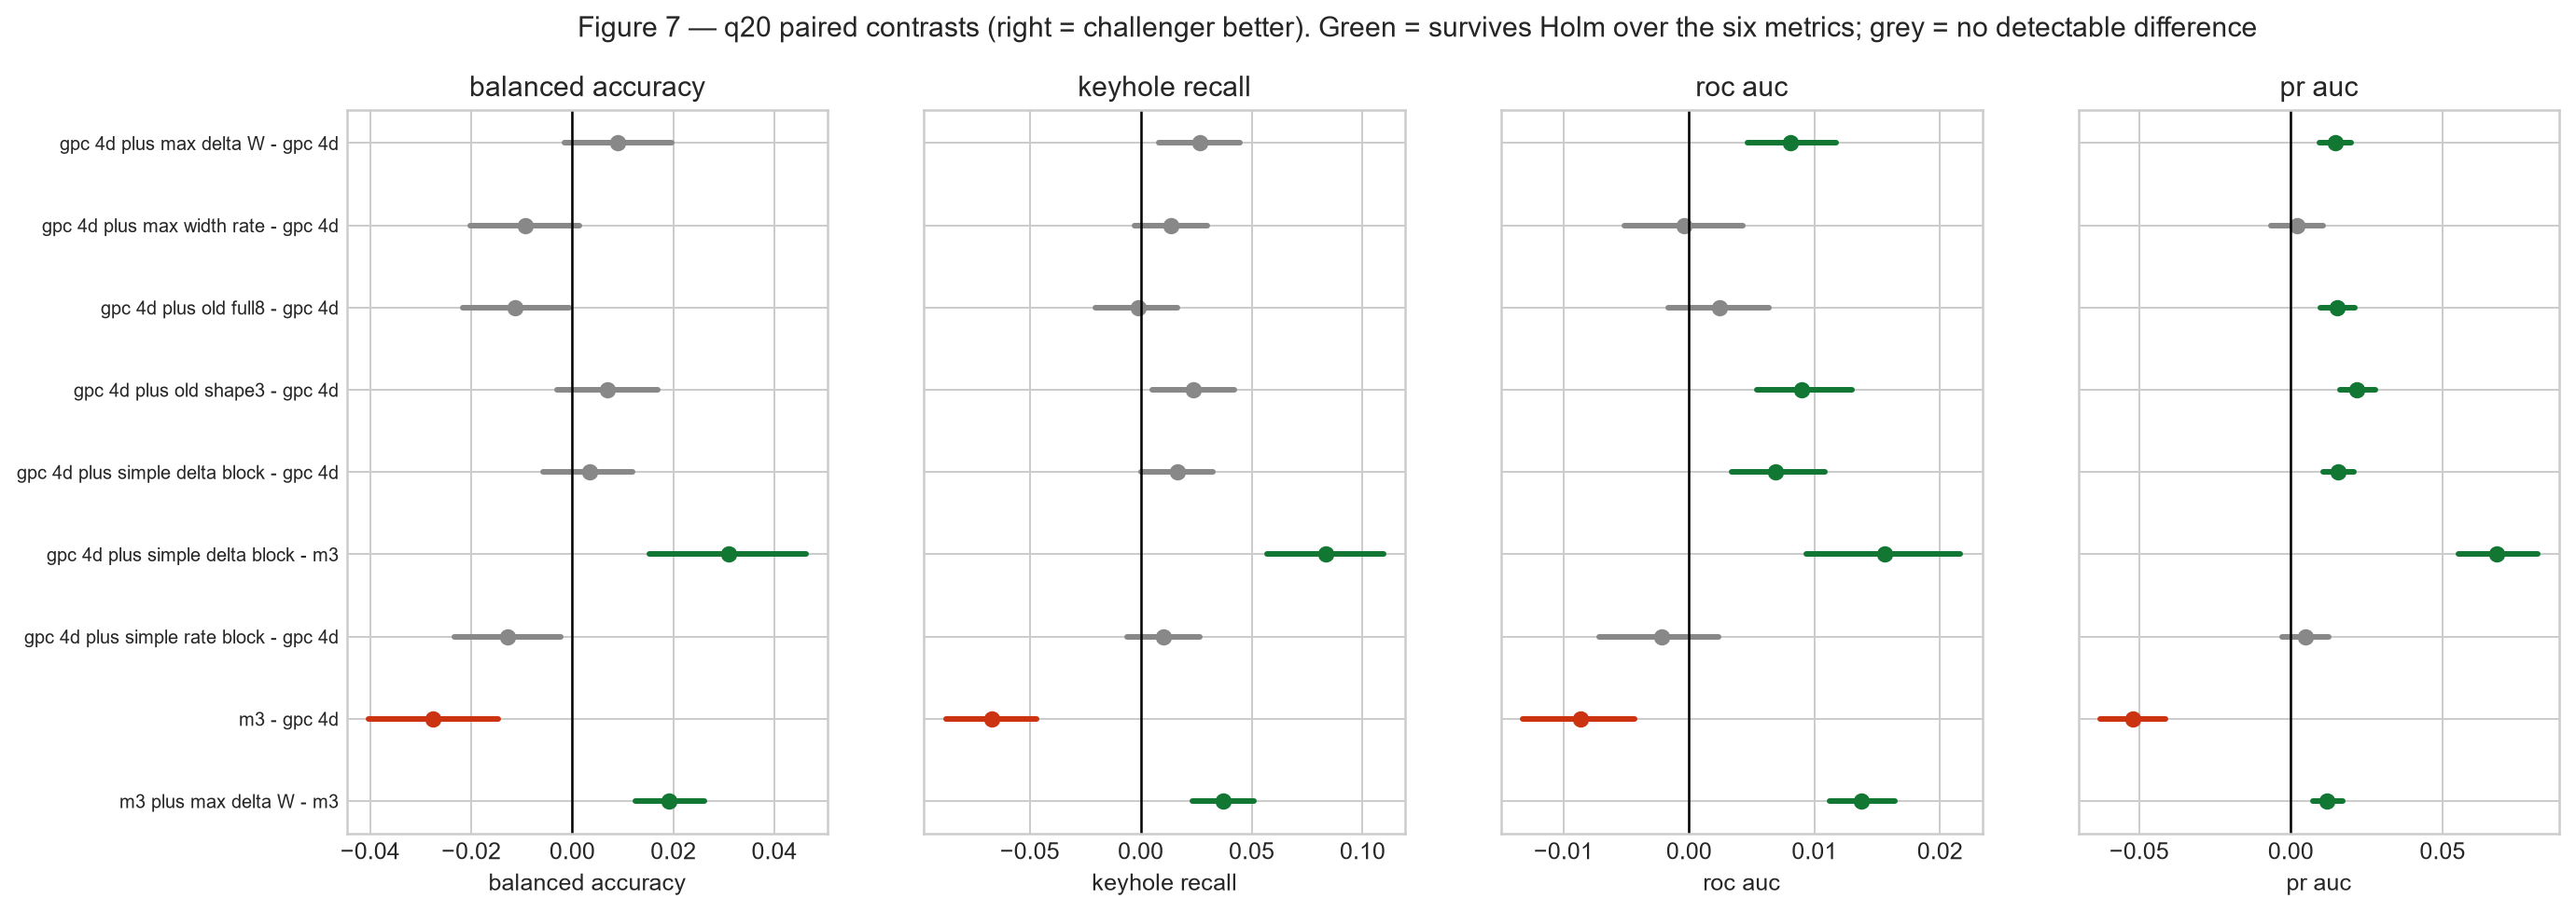

In [8]:
inf = pd.read_csv(OUT/'contrast_inference.csv')
display(inf[(inf.subset=='q20') & inf.contrast_role.isin(['primary','m3_context'])][['contrast','metric','mean_difference','ci_low','ci_high','holm_p_metric_family','verdict_after_holm']].round(4))
display(Image(filename=OUT/'figures'/'07_q20_paired_contrasts.png'))


## 8. Is any of this just the grid resolution?

The 201-point grid is a choice we made, not a physical constant. If the answer flipped when we used 51 or 101 points instead, it would be an artifact of that choice rather than a fact about melt pools. So every headline feature is rebuilt on exact subsamples of the same grid and compared.


,feature,plain_english,cliffs_delta_51,cliffs_delta_101,cliffs_delta_201,roc_auc_51,roc_auc_101,roc_auc_201,direction_consistent,interval_excludes_zero_everywhere,resolution_robust
0,max_positive_delta_W,largest increase in transverse width between two consecutive resampled analysis points,-0.3121,-0.1623,-0.2042,0.3439,0.4188,0.3979,True,False,False
1,min_delta_W,"most negative transition, i.e. the largest single contraction",-0.2332,-0.0018,0.1594,0.3834,0.4991,0.5797,False,False,False
2,median_positive_delta_W,median of only the transitions where the width grew,-0.1389,-0.1349,-0.0861,0.4306,0.4326,0.4569,True,False,False
3,fraction_positive_delta_W,share of transitions in which the width increased,-0.2129,-0.1269,0.0001,0.3936,0.4365,0.5001,False,False,False
4,total_positive_delta_W,"sum of every increase, i.e. total growth ignoring the shrinking steps",0.1333,0.0735,0.0006,0.5666,0.5367,0.5003,True,False,False
5,max_positive_width_rate,largest increase divided by the time gap it happened in (um per ms),-0.3335,-0.2318,-0.3001,0.3333,0.3841,0.3499,True,True,True
6,median_positive_width_rate,median of the positive rises after each is divided by its own time gap,-0.2306,-0.2573,-0.2444,0.3847,0.3713,0.3778,True,True,True
7,fraction_positive_width_rate,share of transitions with a positive rate -- identical to fraction_positive_delta_W be...,-0.2129,-0.1269,0.0001,0.3936,0.4365,0.5001,False,False,False


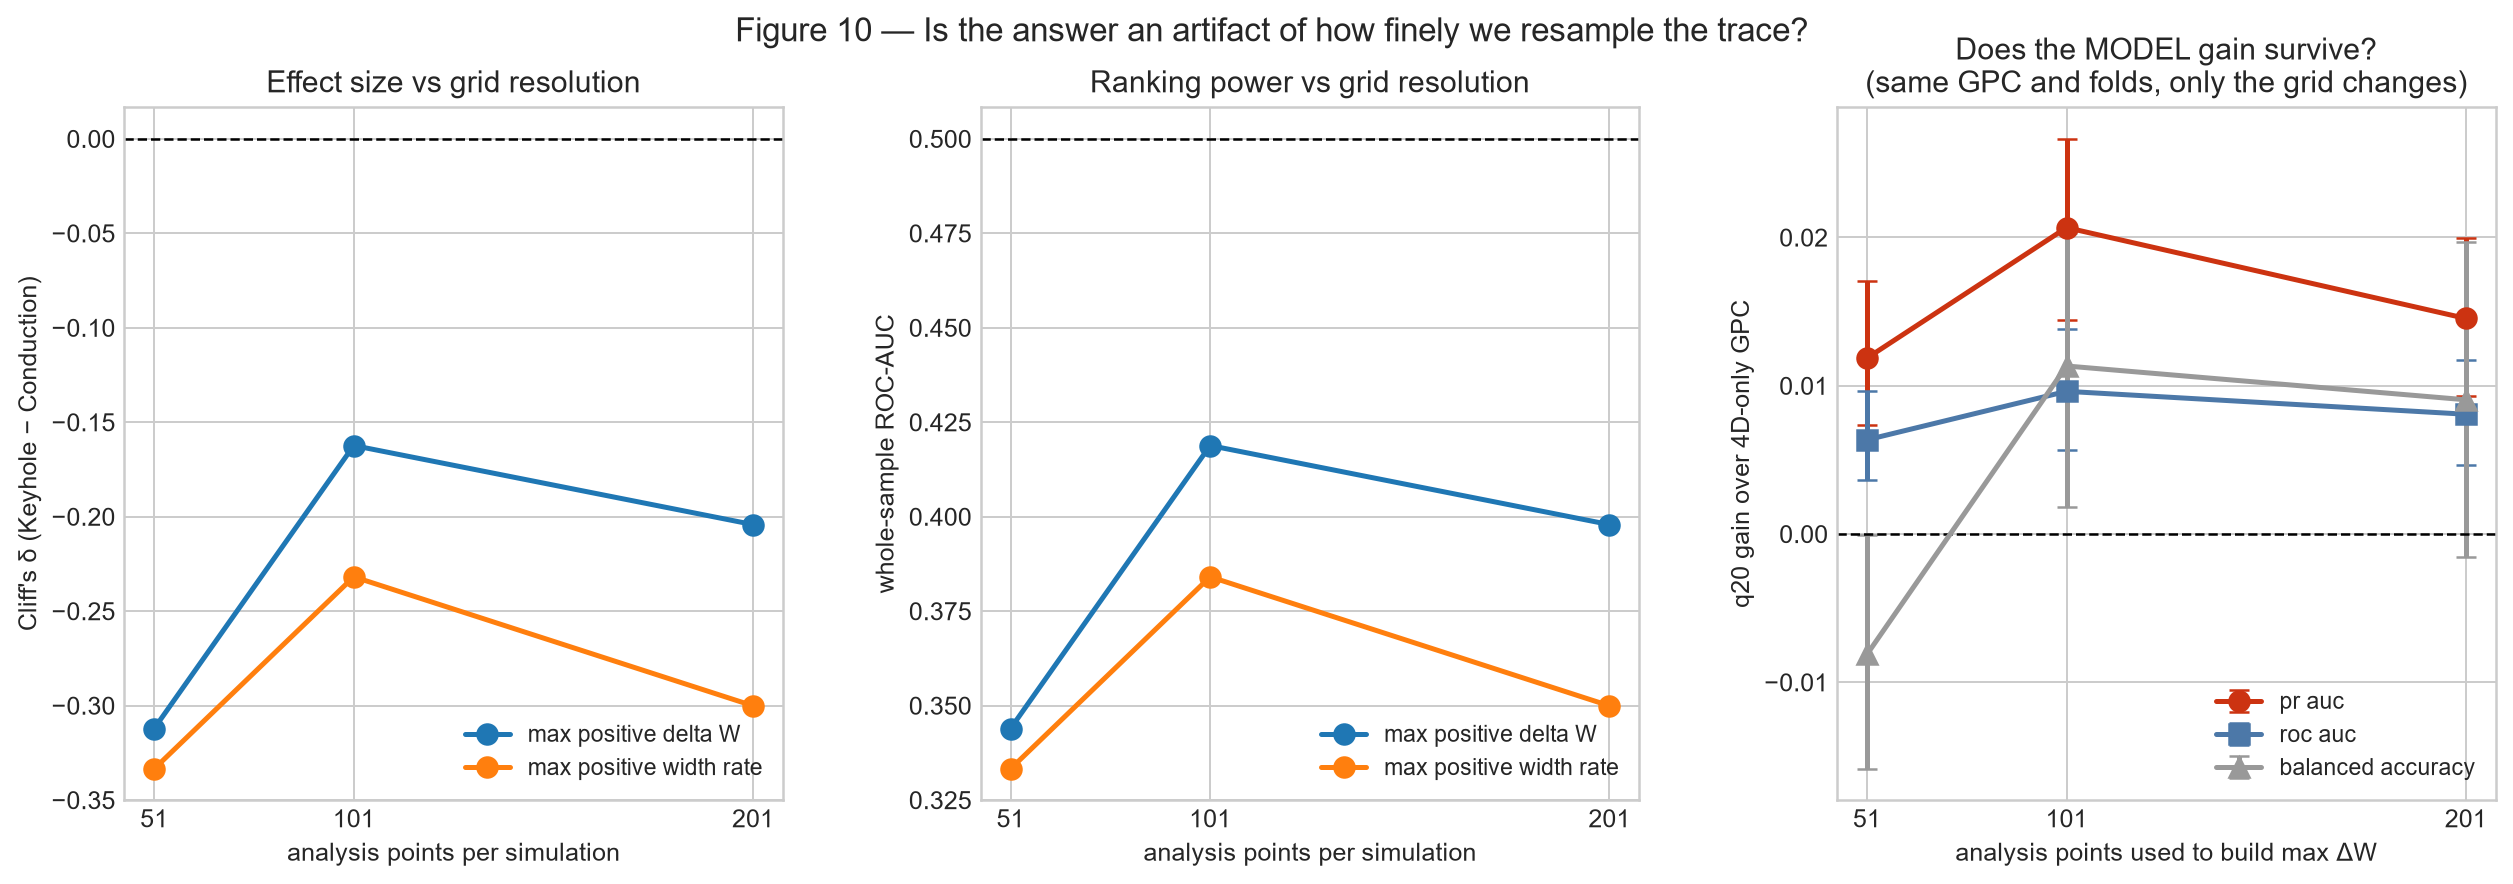

In [9]:
display(pd.read_csv(OUT/'resolution_robustness_verdict.csv').round(4))
display(Image(filename=OUT/'figures'/'10_resolution_sweep.png'))


## 9. The old engineered features, demoted — and the derivative ablation

Phase 2.1 summarised the width trace using engineered shape and derivative descriptors. Phase 2.1R instead asks the simpler question: what happens between consecutive resampled analysis points?

The old blocks are kept only for context, now run under GPC instead of logistic regression. The ablation starts from 4D + the three shape features and adds each of the five robust derivative features back one at a time, to see whether one of them does the damage or whether the group dilutes collectively.


,contrast,mean_difference,ci_low,ci_high,holm_p_metric_family,verdict_after_holm
7,abl_shape3_plus_robust_early_dWdt_20_um_per_ms - gpc_4d_plus_old_shape3,-0.0031,-0.0089,0.0026,0.5912,NO DETECTABLE DIFFERENCE
25,abl_shape3_plus_robust_early_dWdt_40_um_per_ms - gpc_4d_plus_old_shape3,-0.0068,-0.0124,-0.0013,0.1368,NO DETECTABLE DIFFERENCE
43,abl_shape3_plus_robust_max_positive_dWdt_um_per_ms - gpc_4d_plus_old_shape3,-0.0020,-0.0096,0.0048,1.0000,NO DETECTABLE DIFFERENCE
61,abl_shape3_plus_robust_median_positive_dWdt_um_per_ms - gpc_4d_plus_old_shape3,-0.0014,-0.0036,0.0000,1.0000,NO DETECTABLE DIFFERENCE
79,abl_shape3_plus_robust_time_of_max_dWdt_tau - gpc_4d_plus_old_shape3,-0.0080,-0.0106,-0.0053,0.0009,DEGRADES
187,gpc_4d_plus_old_full8 - gpc_4d_plus_old_shape3,-0.0183,-0.0276,-0.0089,0.0095,DEGRADES


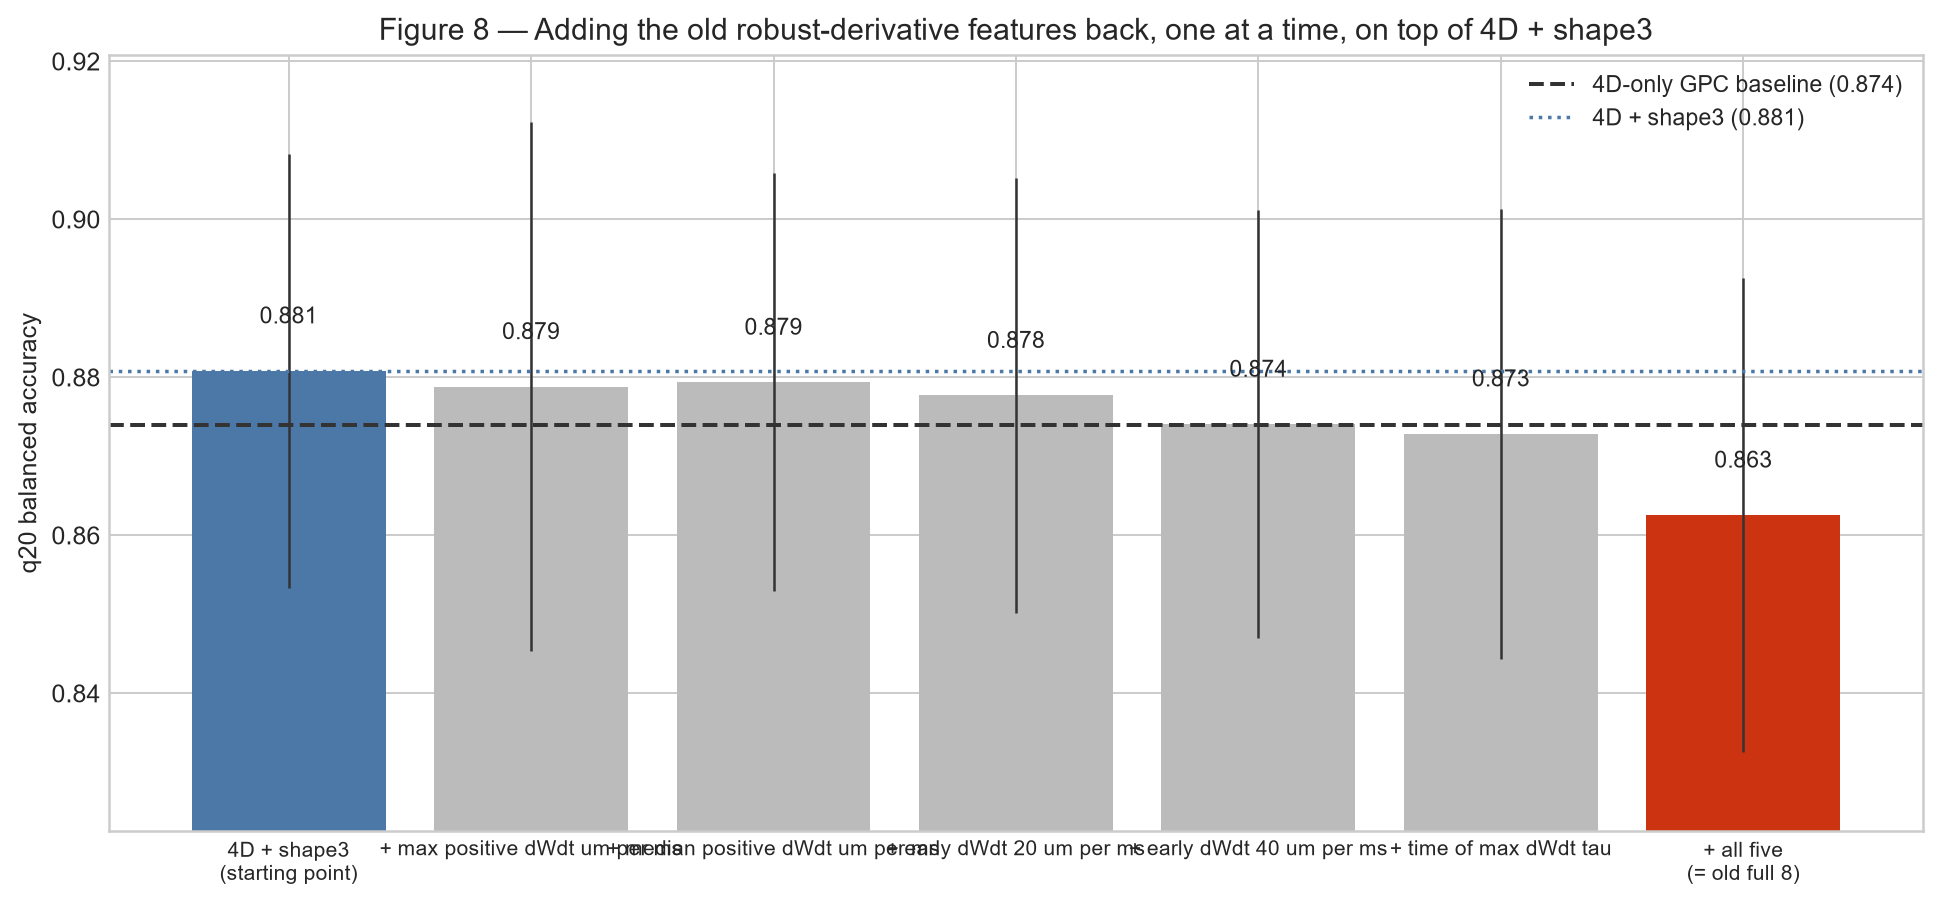

In [10]:
display(inf[(inf.contrast_role=='ablation') & (inf.subset=='q20') & (inf.metric=='balanced_accuracy')][['contrast','mean_difference','ci_low','ci_high','holm_p_metric_family','verdict_after_holm']].round(4))
display(Image(filename=OUT/'figures'/'08_derivative_ablation.png'))


## 10. Corrections to what Phase 2.1 said

Three statements in the Phase 2.1 write-up were wrong or overstated, and are corrected here against the recomputed numbers.


In [11]:
display(pd.read_csv(OUT/'phase2_1_corrections.csv'))


,previous_statement,verdict,correction,evidence
0,nothing anywhere survives the Holm adjustment,WRONG,"Within the six-metric Holm family, 2 results survive at the 0.05 level: q30 pr_auc +0....",outputs/week9_phase2_1_fourd_plus_width_control/model_paired_contrasts.csv
1,width adds no value beyond the 4D process inputs,OVERSTATED,Safe wording: the full eight-feature width block did not show a supported q20 improvem...,"same file, contrast 4d_plus_width_shape_only - 4d_only"
2,width dynamics is redundant because R-squared = 0.58,CAUSALLY OVERSTATED,Safe wording: several width-derived features are substantially predictable from the pr...,outputs/week9_phase2_1_fourd_plus_width_control/width_vs_4d_collinearity.csv
3,the engineered eight-feature block is the width story,SUPERSEDED,Phase 2.1 summarised the width trace using engineered shape and derivative descriptors...,this phase


## 11. What is supported, what is not

The claim ledger is the contract. A whole-sample difference is not a held-out gain; a ranking gain is not a hard-classification gain; and nothing here transfers to simulations that never produced a usable trace.


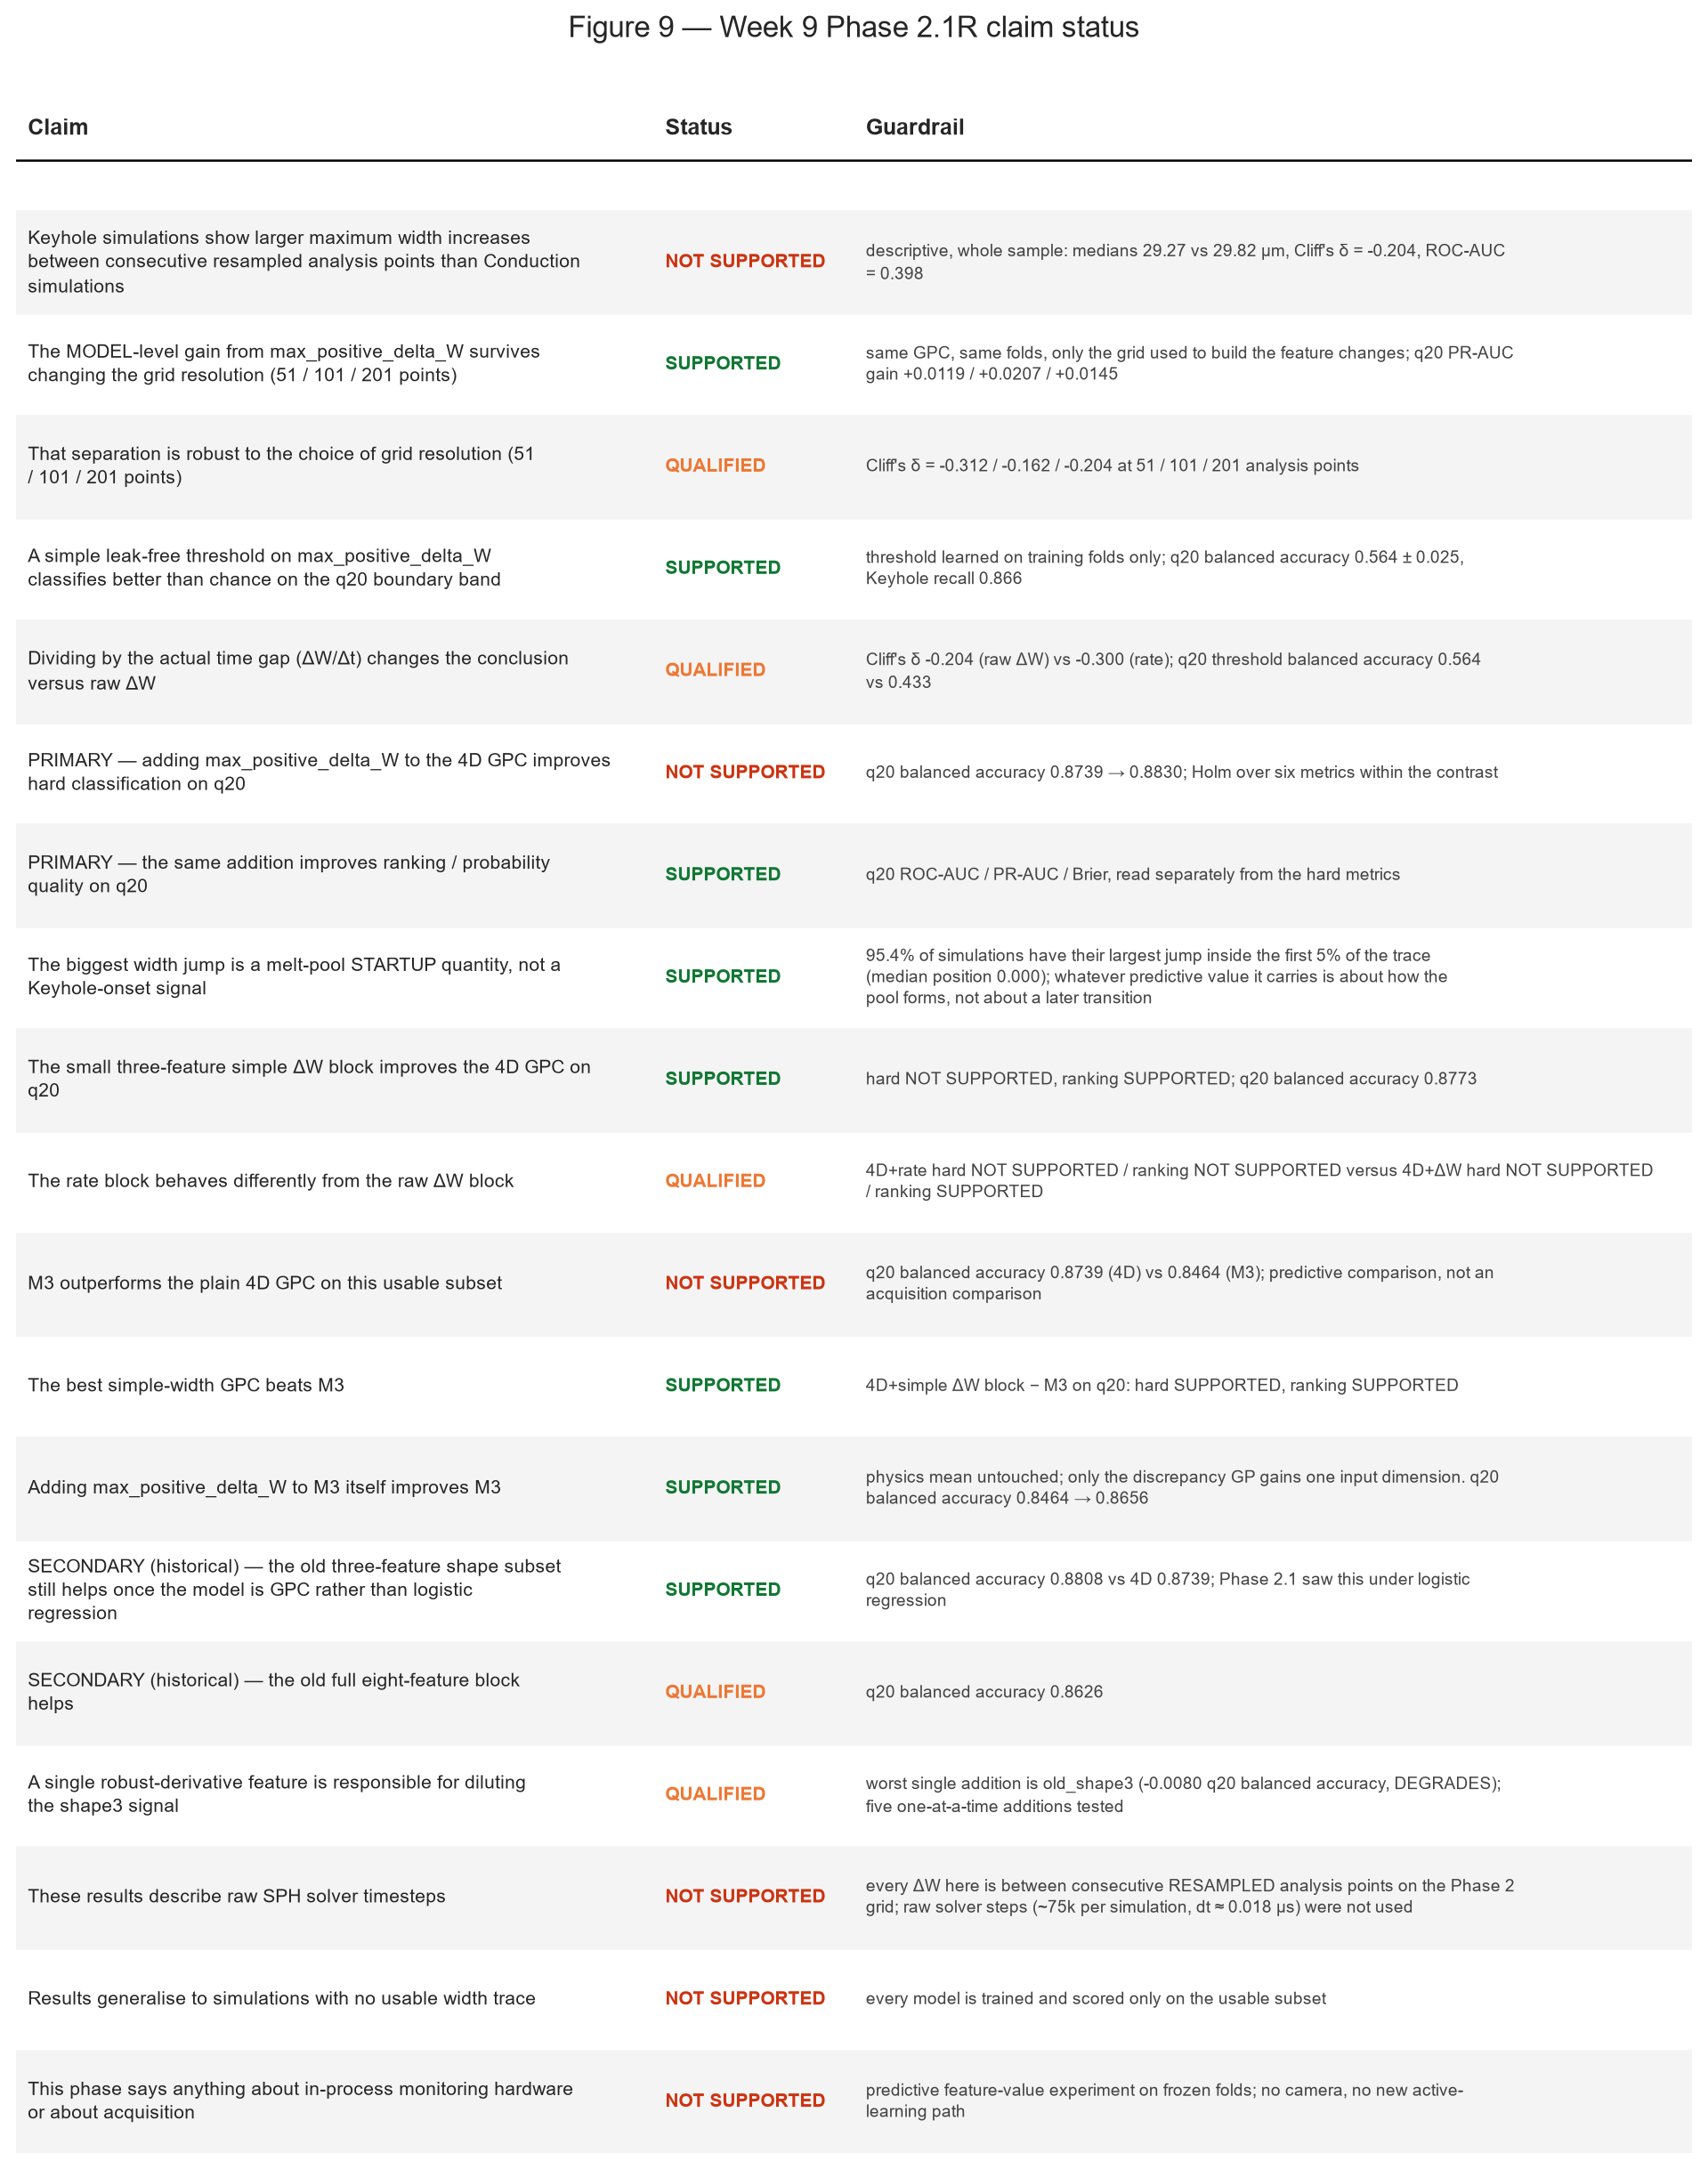

PASS


In [12]:
display(Image(filename=OUT/'figures'/'09_claim_status.png'))
print(json.loads((OUT/'validation_report.json').read_text(encoding='utf-8'))['status'])


## 12. The four interactive 3D views

The process space has four inputs, so no single 3D picture can show it. Four views each drop one input from the axes and keep it as a colour mode and a hover field, so every input gets a turn being the hidden one. Open `interactive_3d_index.html` to reach all four. They work offline with no libraries.


In [13]:
idx = OUT/'interactive_3d_index.html'
print(idx.name, '|', round(idx.stat().st_size/1024, 1), 'KB')
for p in sorted((OUT/'interactive').glob('*.html')):
    print(' ', p.name, '|', round(p.stat().st_size/1024, 1), 'KB')


interactive_3d_index.html | 3.4 KB
  view1_drop_ST.html | 109.4 KB
  view2_drop_LS.html | 109.4 KB
  view3_drop_VX.html | 109.4 KB
  view4_drop_P.html | 109.4 KB
